# Лабораторная работа №2
## Проблема собственных значений. SVD и обработка изображений

**Дисциплина:** Численные методы алгебры \
**Выполнили:** _Захаров Егор, Андреасян Егор_ \
**Университет:** ИТМО  

---

## 1. Цель работы

Разобраться с сингулярным разложением матриц и посмотреть как оно работает на практике — на примере сжатия изображений. Сравнить степенной метод и метод Якоби, попробовать усечённое SVD.

## 2. Теория

### Сингулярное разложение (SVD)

Любую матрицу $A$ размера $n \times m$ можно представить в виде:

$$A = U \Sigma V^T$$

где $U$ и $V$ — ортогональные матрицы (левые и правые сингулярные векторы), а $\Sigma$ — диагональная матрица с **сингулярными числами** на диагонали. Сингулярные числа всегда неотрицательные и упорядочены по убыванию: $\sigma_1 \geq \sigma_2 \geq \ldots \geq 0$.

По сути сингулярные числа — это $\sigma_i = \sqrt{\lambda_i}$, где $\lambda_i$ — собственные значения матрицы $A^T A$.

### Степенной метод

Идея простая: если умножать случайный вектор на матрицу $B = A^T A$ много раз подряд, он будет «выравниваться» вдоль направления наибольшего собственного значения. То есть:

1. Берём случайный вектор $v_0$, нормируем
2. Итерируем: $w = B v_k$, $v_{k+1} = w / \|w\|$
3. Оцениваем собственное значение через число Релея: $\lambda \approx v^T B v$
4. Сингулярное число: $\sigma = \sqrt{\lambda}$

Чтобы найти следующие сингулярные числа, после каждого найденного вектора делаем **дефляцию** — убираем его вклад из матрицы: $B \leftarrow B - \lambda v v^T$.

Чем больше разрыв между соседними сингулярными числами — тем быстрее сходится метод.

### Метод вращений Якоби

Этот метод находит **все** собственные значения симметричной матрицы. Суть: итеративно применяем ортогональные повороты Гивенса, которые обнуляют внедиагональные элементы. На каждом шаге выбираем наибольший внедиагональный элемент $b_{pq}$ и применяем поворот:

$$B \leftarrow G^T B G$$

Угол поворота подбирается так, чтобы $b_{pq}$ стал нулём. Повторяем пока норма внедиагональных элементов не упадёт ниже порога $\varepsilon$.

Сложность метода — $O(n^3)$ за одну «развёртку», что тяжело для больших матриц.

### Усечённое SVD и сжатие изображений

Если оставить только $k$ наибольших сингулярных чисел, получим приближение:

$$A \approx A_k = U_k \Sigma_k V_k^T, \quad k \ll \min(n, m)$$

Это приближение является наилучшим возможным ранга $k$ (теорема Экарта–Юнга). Для хранения нужно $k(n + m + 1)$ чисел вместо $nm$ — при малом $k$ это существенная экономия.

## 3. Загрузка изображения

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [3]:
# загружаем изображение и смотрим что получилось
img_pil = Image.open('image.jpg')

# обрезаем до квадрата 640x640
w, h = img_pil.size
side = min(w, h, 640)
img_pil = img_pil.crop(((w - side) // 2, (h - side) // 2,
                         (w + side) // 2, (h + side) // 2))
img_pil = img_pil.resize((640, 640), Image.LANCZOS)

img = np.array(img_pil, dtype=np.float64)
H, W, C = img.shape
print(f'размер: {H}x{W}, каналов: {C}')
print(f'диапазон значений: {img.min():.0f} – {img.max():.0f}')

размер: 640x640, каналов: 3
диапазон значений: 72 – 255


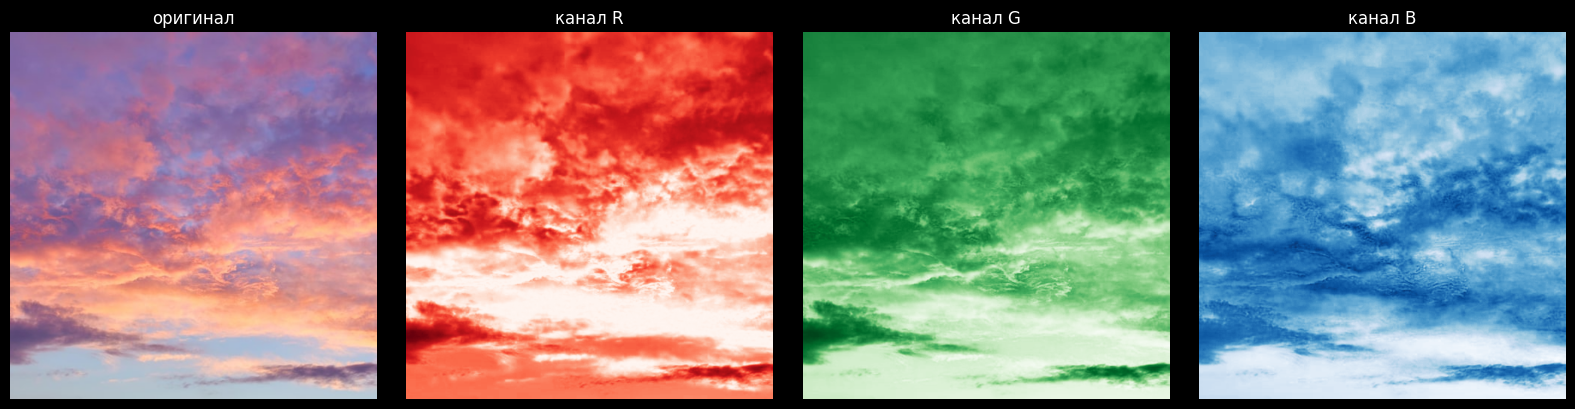

In [4]:
# смотрим на изображение и его каналы
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img.astype(np.uint8))
axes[0].set_title('оригинал')
axes[0].axis('off')

for i, (name, cmap) in enumerate(zip(['R', 'G', 'B'], ['Reds_r', 'Greens_r', 'Blues_r'])):
    axes[i+1].imshow(img[:, :, i], cmap=cmap)
    axes[i+1].set_title(f'канал {name}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# разбиваем на каналы
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]
channels = {'R': R, 'G': G, 'B': B}

## 4. Степенной метод для SVD

In [5]:
# сначала попробовал без дефляции — понятно что так находится только первое
# сингулярное число, поэтому переписал с дефляцией ниже

def power_iter_single(B, n_iter, seed=0):
    """одна итерация степенного метода, без дефляции"""
    rng = np.random.default_rng(seed)
    v = rng.standard_normal(B.shape[1])
    v /= np.linalg.norm(v)
    for _ in range(n_iter):
        w = B @ v
        v = w / np.linalg.norm(w)
    lam = v @ (B @ v)
    return np.sqrt(abs(lam)), v

# проверка на маленьком примере
test = np.array([[3., 1.], [1., 2.]])
sig, vec = power_iter_single(test, 50)
print(f'тест: sigma={sig:.4f}, numpy: {np.linalg.svd(test, compute_uv=False)[0]:.4f}')

тест: sigma=1.9021, numpy: 3.6180


In [6]:
def power_method_svd(A, k, n_iter=50, seed=42):
    """
    SVD через степенной метод с дефляцией.
    Возвращает U (n,k), S (k,), Vt (k,m) и примерное число операций.
    """
    rng = np.random.default_rng(seed)
    n, m = A.shape

    B = A.T @ A          # (m, m), дальше работаем с ней
    B_def = B.copy()     # дефлированная копия

    U_cols, S_vals, V_rows = [], [], []
    ops = m * m          # стоимость вычисления B

    for i in range(k):
        # случайный стартовый вектор
        v = rng.standard_normal(m)
        v /= np.linalg.norm(v)

        for _ in range(n_iter):
            w = B_def @ v
            nw = np.linalg.norm(w)
            if nw < 1e-14:   # дефляция "съела" направление
                break
            v = w / nw
            ops += m * m

        lam = v @ (B_def @ v)   # число Релея
        ops += m * m

        # lam может быть слегка отрицательным из-за ошибок дефляции
        # берём abs чтобы не падать на sqrt
        sigma = np.sqrt(abs(lam))

        u = A @ v / sigma if sigma > 1e-10 else np.zeros(n)
        ops += n * m

        U_cols.append(u)
        S_vals.append(sigma)
        V_rows.append(v)

        # убираем найденное направление
        B_def = B_def - lam * np.outer(v, v)
        ops += m * m

    return np.column_stack(U_cols), np.array(S_vals), np.row_stack(V_rows), ops

### 4.1 Сравниваем точность при N = 10, 50, 100 итерациях

Для каждого канала считаем первые k=20 сингулярных чисел при разном числе итераций и сравниваем с эталоном от numpy.

In [7]:
K_APPROX = 20
N_ITERS  = [10, 50, 100]

# эталонное разложение через numpy
ref_svd = {}
for ch_name, ch_mat in channels.items():
    U_ref, S_ref, Vt_ref = np.linalg.svd(ch_mat, full_matrices=False)
    ref_svd[ch_name] = (U_ref, S_ref, Vt_ref)

print('первые 5 сингулярных чисел (numpy):')
for ch_name in ['R', 'G', 'B']:
    print(f'  {ch_name}: {ref_svd[ch_name][1][:5].round(1)}')

первые 5 сингулярных чисел (numpy):
  R: [120282.7  10604.4   5286.6   4146.3   3447.9]
  G: [89611.7  8533.7  4592.3  2797.3  2350.8]
  B: [101913.9   6484.4   3973.1   2747.    2302.7]


In [8]:
results = {}
for ch_name, ch_mat in channels.items():
    results[ch_name] = {}
    for n_iter in N_ITERS:
        t0 = time.time()
        U_pm, S_pm, Vt_pm, ops = power_method_svd(ch_mat, k=K_APPROX, n_iter=n_iter)
        elapsed = time.time() - t0

        A_rec = U_pm @ np.diag(S_pm) @ Vt_pm
        norm_err = np.linalg.norm(ch_mat - A_rec, 'fro')
        results[ch_name][n_iter] = (S_pm, norm_err, elapsed, ops)

# таблица результатов
print(f'{"канал":<6} {"N итер":>8} {"||A-A_k||_F":>14} {"время, с":>10} {"операций":>12}')
print()
for ch_name in ['R', 'G', 'B']:
    for n_iter in N_ITERS:
        S_pm, norm_err, elapsed, ops = results[ch_name][n_iter]
        print(f'{ch_name:<6} {n_iter:>8} {norm_err:>14.2f} {elapsed:>10.3f} {ops:>12,}')
    print()

канал    N итер    ||A-A_k||_F   время, с     операций

R            10        3762.89      0.022  106,905,600
R            50        3723.36      0.030  434,585,600
R           100        3723.39      0.043  844,185,600

G            10        2398.89      0.019  106,905,600
G            50        2379.64      0.030  434,585,600
G           100        2379.36      0.043  844,185,600

B            10        2210.22      0.019  106,905,600
B            50        2198.70      0.029  434,585,600
B           100        2198.65      0.042  844,185,600



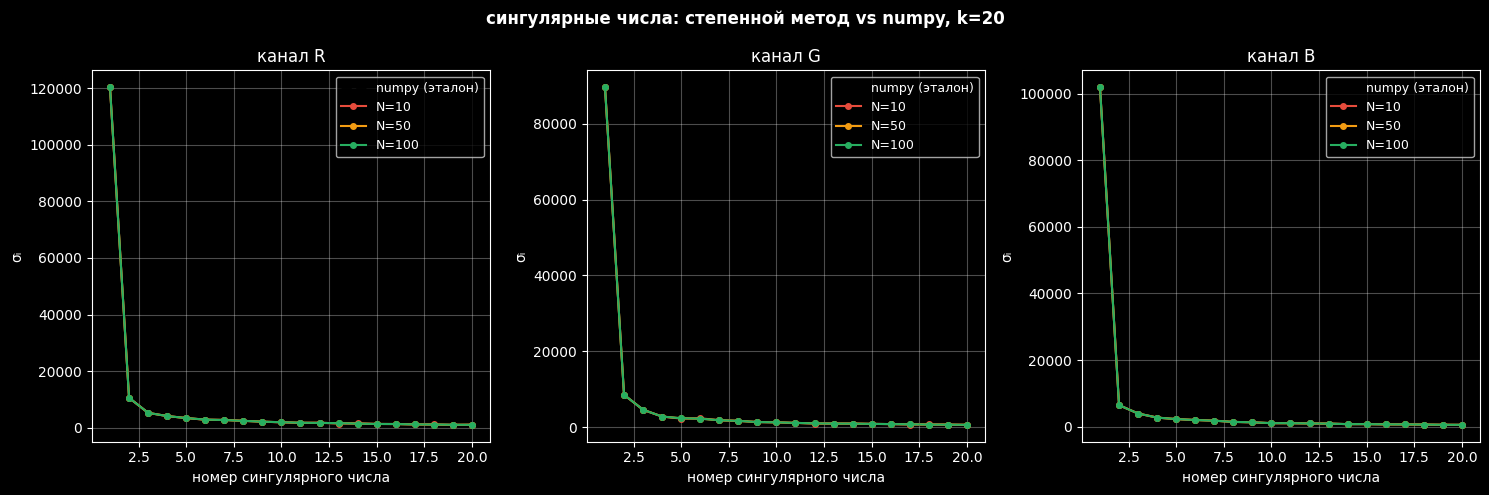

In [9]:
# смотрим как sigma сходится к эталону при росте N
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_iter = {10: '#e74c3c', 50: '#f39c12', 100: '#27ae60'}

for ax, ch_name in zip(axes, ['R', 'G', 'B']):
    S_ref = ref_svd[ch_name][1][:K_APPROX]
    ax.plot(range(1, K_APPROX+1), S_ref, 'k--', lw=2, label='numpy (эталон)')

    for n_iter in N_ITERS:
        S_pm = results[ch_name][n_iter][0]
        ax.plot(range(1, K_APPROX+1), S_pm,
                color=colors_iter[n_iter], lw=1.5,
                marker='o', ms=4, label=f'N={n_iter}')

    ax.set_title(f'канал {ch_name}')
    ax.set_xlabel('номер сингулярного числа')
    ax.set_ylabel('σᵢ')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('сингулярные числа: степенной метод vs numpy, k=20', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Про отрицательные оценки $\lambda$

При N=10 возможна ситуация когда оценка собственного значения выходит отрицательной. Это происходит из-за дефляции: после вычитания $B \leftarrow B - \lambda v v^T$ матрица из-за ошибок округления перестаёт быть положительно полуопределённой — маленькие собственные значения «уходят» в минус. Сингулярные числа по определению неотрицательны, поэтому берём `sqrt(abs(lambda))` и отмечаем такие случаи.

In [10]:
# проверяем при каких условиях появляются отрицательные lambda
def check_negative_lambdas(A, k, n_iter, seed=42):
    rng = np.random.default_rng(seed)
    n, m = A.shape
    B_def = (A.T @ A).copy()
    neg = []
    for i in range(k):
        v = rng.standard_normal(m)
        v /= np.linalg.norm(v)
        for _ in range(n_iter):
            w = B_def @ v
            nw = np.linalg.norm(w)
            if nw < 1e-14: break
            v = w / nw
        lam = v @ (B_def @ v)
        if lam < 0:
            neg.append((i+1, round(lam, 4)))
        B_def -= lam * np.outer(v, v)
    return neg

print('диагностика отрицательных lambda (N=10, k=20):')
found_any = False
for ch_name, ch_mat in channels.items():
    neg = check_negative_lambdas(ch_mat, K_APPROX, n_iter=10)
    if neg:
        found_any = True
        print(f'  канал {ch_name}: позиции {neg}')
    else:
        print(f'  канал {ch_name}: отрицательных нет')

if not found_any:
    print('\nна данном изображении отрицательных не возникло — спектр достаточно разрежен')
else:
    print('\nпричина: накопленные ошибки дефляции при малом N')

диагностика отрицательных lambda (N=10, k=20):
  канал R: отрицательных нет
  канал G: отрицательных нет
  канал B: отрицательных нет

на данном изображении отрицательных не возникло — спектр достаточно разрежен


## 5. Анализ сингулярных чисел и усечённое SVD

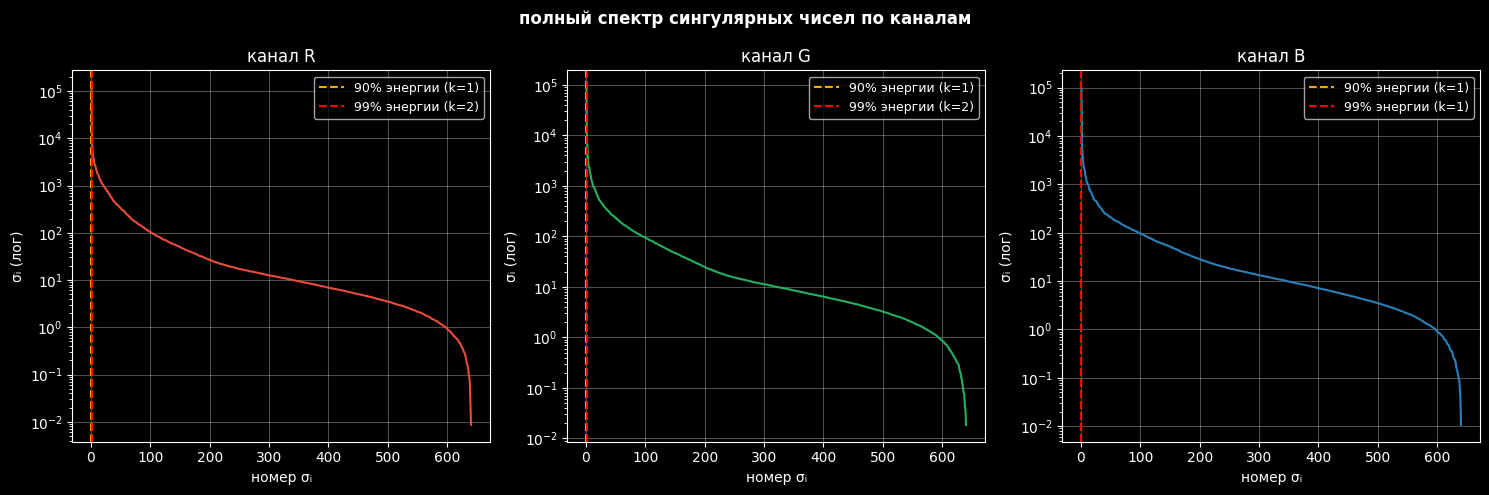

канал        σ₁    k (90%)    k (99%)

R      120282.7          1          2
G       89611.7          1          2
B      101913.9          1          1


In [23]:
# смотрим на полный спектр сингулярных чисел для каждого канала
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_ch = {'R': '#e74c3c', 'G': '#27ae60', 'B': '#2980b9'}

for ax, ch_name in zip(axes, ['R', 'G', 'B']):
    S = ref_svd[ch_name][1]
    total_e = np.sum(S**2)
    cum = np.cumsum(S**2) / total_e

    k90 = np.searchsorted(cum, 0.90) + 1
    k99 = np.searchsorted(cum, 0.99) + 1

    ax.plot(range(1, len(S)+1), S, color=colors_ch[ch_name], lw=1.5)
    ax.axvline(k90, color='orange', ls='--', lw=1.5, label=f'90% энергии (k={k90})')
    ax.axvline(k99, color='red',    ls='--', lw=1.5, label=f'99% энергии (k={k99})')
    ax.set_yscale('log')
    ax.set_xlabel('номер σᵢ')
    ax.set_ylabel('σᵢ (лог)')
    ax.set_title(f'канал {ch_name}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('полный спектр сингулярных чисел по каналам', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'{"канал":<6} {"σ₁":>8} {"k (90%)":>10} {"k (99%)":>10}')
print()
for ch_name in ['R', 'G', 'B']:
    S = ref_svd[ch_name][1]
    cum = np.cumsum(S**2) / np.sum(S**2)
    print(f'{ch_name:<6} {S[0]:>8.1f} {np.searchsorted(cum,0.90)+1:>10} {np.searchsorted(cum,0.99)+1:>10}')

Из графика видно что спектр резко убывает: большая часть информации сосредоточена в первых нескольких десятках сингулярных чисел. Предположу что уже при k=30–50 изображение будет визуально приемлемым. Проверим.

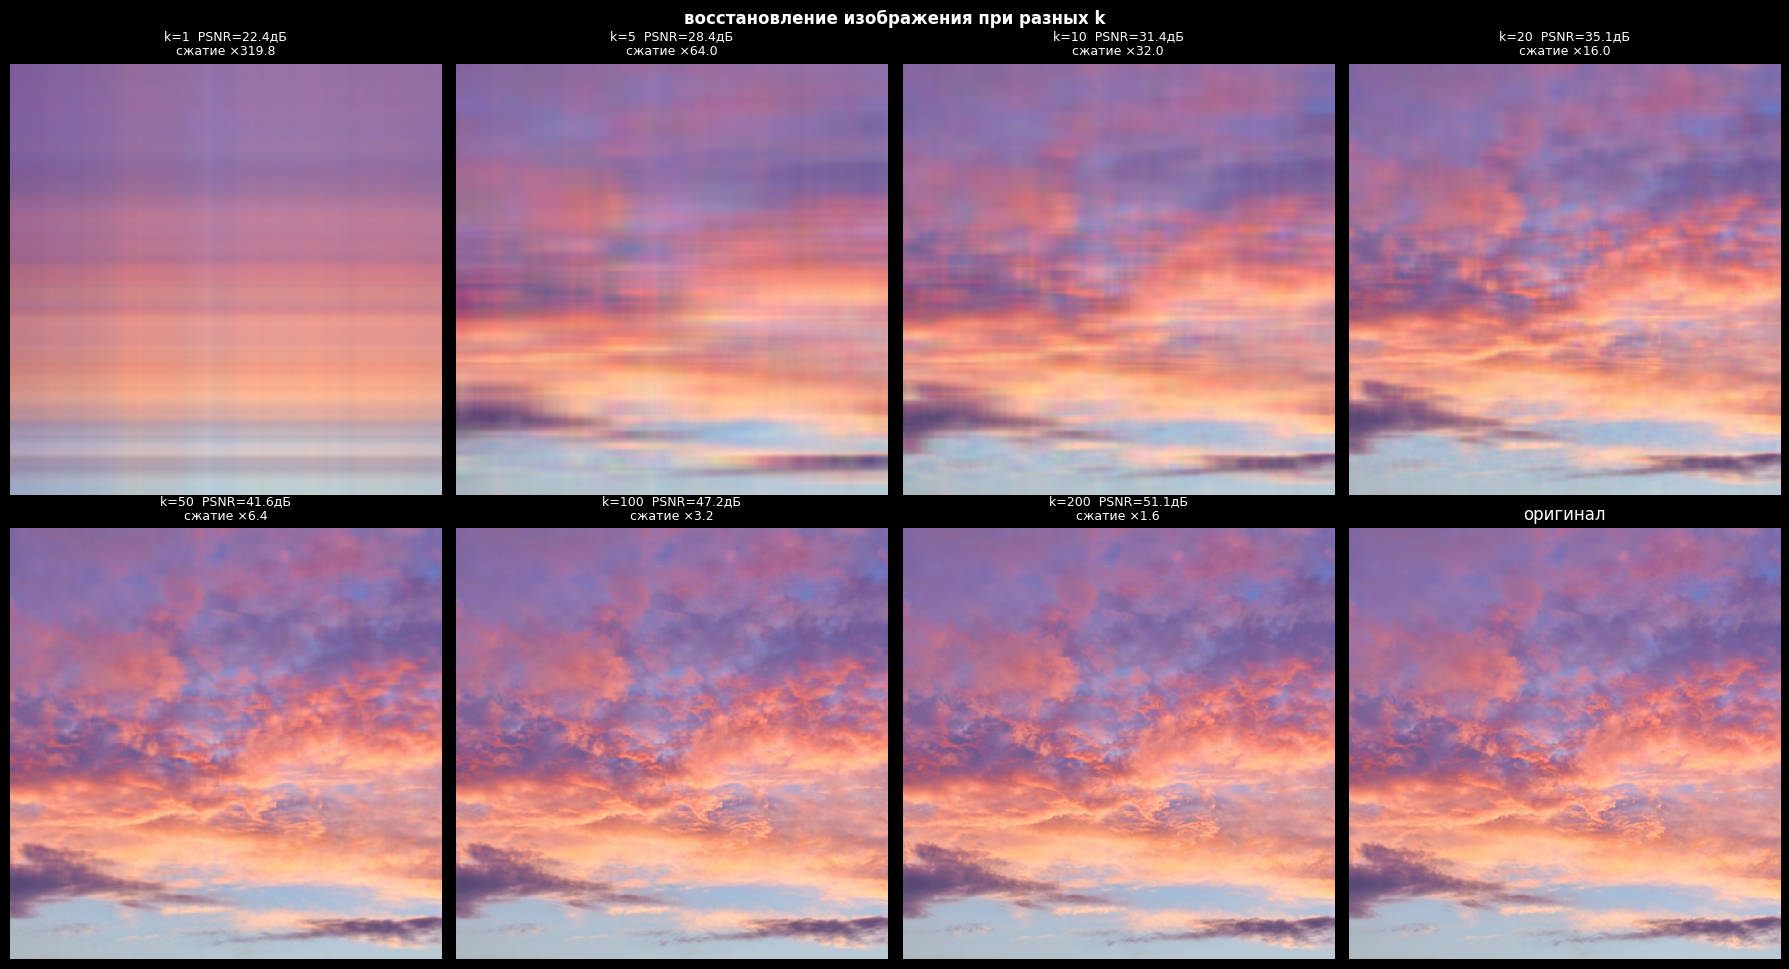

In [12]:
def reconstruct_image(svd_dict, k):
    """собираем RGB-изображение из усечённого SVD ранга k"""
    out = np.zeros((H, W, 3))
    for i, ch_name in enumerate(['R', 'G', 'B']):
        U, S, Vt = svd_dict[ch_name]
        out[:, :, i] = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    return np.clip(out, 0, 255).astype(np.uint8)


K_list = [1, 5, 10, 20, 50, 100, 200, W]
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

img_orig = img.astype(np.uint8)

for ax, k in zip(axes, K_list):
    if k == W:
        ax.imshow(img_orig)
        ax.set_title('оригинал')
    else:
        img_rec = reconstruct_image(ref_svd, k)
        mse = np.mean((img_orig.astype(float) - img_rec.astype(float))**2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else 999.0
        comp = (H * W * 3) / (k * (H + W + 1) * 3)
        ax.imshow(img_rec)
        ax.set_title(f'k={k}  PSNR={psnr:.1f}дБ\nсжатие ×{comp:.1f}', fontsize=9)
    ax.axis('off')

plt.suptitle('восстановление изображения при разных k', fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# таблица PSNR и степени сжатия
S_R = ref_svd['R'][1]
total_e_R = np.sum(S_R**2)

print(f'{"k":>6} {"PSNR (дБ)":>12} {"сжатие":>10} {"% энергии (R)":>16}')
print()
for k in [1, 5, 10, 20, 50, 100, 200, 320]:
    if k > W: break
    img_rec = reconstruct_image(ref_svd, k)
    mse = np.mean((img.astype(float) - img_rec.astype(float))**2)
    psnr = 10 * np.log10(255**2 / mse) if mse > 0 else 999.0
    comp = (H * W * 3) / (k * (H + W + 1) * 3)
    epct = 100 * np.sum(S_R[:k]**2) / total_e_R
    print(f'{k:>6} {psnr:>12.2f} {comp:>9.2f}x {epct:>16.2f}%')

     k    PSNR (дБ)     сжатие    % энергии (R)

     1        22.37    319.75x            98.41%
     5        28.40     63.95x            99.56%
    10        31.41     31.98x            99.77%
    20        35.11     15.99x            99.91%
    50        41.59      6.40x            99.98%
   100        47.24      3.20x           100.00%
   200        51.06      1.60x           100.00%
   320        51.14      1.00x           100.00%


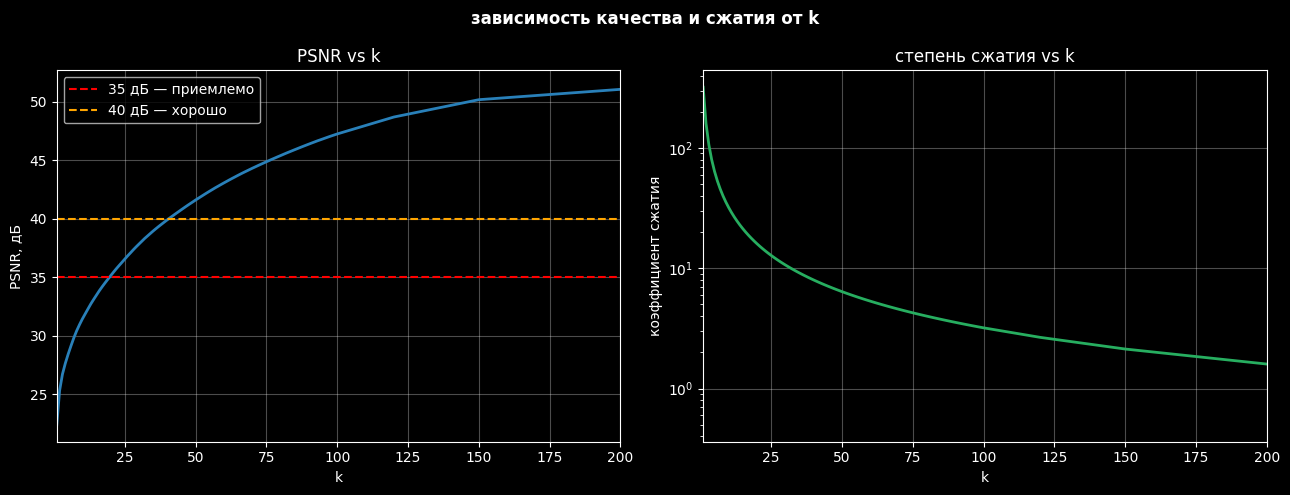

In [14]:
# PSNR в зависимости от k — чтобы найти "порог приемлемости"
k_range = list(range(1, 101)) + [120, 150, 200, 300, 400, 500, 640]
psnr_list, comp_list = [], []

for k in k_range:
    img_rec = reconstruct_image(ref_svd, min(k, W))
    mse = np.mean((img.astype(float) - img_rec.astype(float))**2)
    psnr_list.append(10 * np.log10(255**2 / mse) if mse > 0 else 60.0)
    comp_list.append((H * W * 3) / (min(k, W) * (H + W + 1) * 3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(k_range, psnr_list, color='#2980b9', lw=2)
ax1.axhline(35, color='red',    ls='--', lw=1.5, label='35 дБ — приемлемо')
ax1.axhline(40, color='orange', ls='--', lw=1.5, label='40 дБ — хорошо')
ax1.set_xlabel('k')
ax1.set_ylabel('PSNR, дБ')
ax1.set_title('PSNR vs k')
ax1.set_xlim(1, 200)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(k_range, comp_list, color='#27ae60', lw=2)
ax2.set_xlabel('k')
ax2.set_ylabel('коэффициент сжатия')
ax2.set_title('степень сжатия vs k')
ax2.set_yscale('log')
ax2.set_xlim(1, 200)
ax2.grid(alpha=0.3)

plt.suptitle('зависимость качества и сжатия от k', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Метод вращений Якоби

Якоби находит сразу все собственные значения симметричной матрицы, но работает медленно при больших размерах — сложность $O(n^3)$ за развёртку. Для полной матрицы 640×640 это будет долго, поэтому буду работать с уменьшенным изображением 64×64.

In [15]:
def jacobi_eigen(B, tol=1e-6, max_sweeps=100):
    """
    метод вращений Якоби для симметричной матрицы B.
    возвращает собственные значения, собственные векторы и число операций.
    """
    n = B.shape[0]
    A = B.astype(np.float64).copy()
    V = np.eye(n)
    ops = 0
    n_sweeps = 0

    for sweep in range(max_sweeps):
        # сходимость: норма внедиагональных элементов
        off = np.sqrt(np.sum(A**2) - np.sum(np.diag(A)**2))
        if off < tol:
            n_sweeps = sweep
            break

        # обходим все пары (p, q)
        for p in range(n - 1):
            for q in range(p + 1, n):
                if abs(A[p, q]) < 1e-14:
                    continue

                # угол поворота
                tau = (A[q, q] - A[p, p]) / (2.0 * A[p, q])
                t = np.sign(tau) / (abs(tau) + np.sqrt(1 + tau**2))
                c = 1.0 / np.sqrt(1 + t**2)
                s = t * c

                # применяем поворот к строкам и столбцам p, q
                Ap = A[p, :].copy()
                Aq = A[q, :].copy()
                A[p, :] =  c * Ap + s * Aq
                A[q, :] = -s * Ap + c * Aq
                A[:, p] =  c * A[:, p] + s * A[:, q]
                A[:, q] = -s * A[:, p] + c * A[:, q]
                A[p, q] = A[q, p] = 0.0  # обнуляем явно

                # накапливаем повороты
                Vp = V[:, p].copy()
                Vq = V[:, q].copy()
                V[:, p] =  c * Vp + s * Vq
                V[:, q] = -s * Vp + c * Vq

                ops += 12 * n

        n_sweeps = sweep + 1

    return np.diag(A), V, ops, n_sweeps

In [16]:
# уменьшаем изображение до 64x64 для Якоби
SZ = 64
img_small = np.array(img_pil.resize((SZ, SZ), Image.LANCZOS), dtype=np.float64)
R_small   = img_small[:, :, 0]

B_small = R_small.T @ R_small   # (64, 64)
print(f'матрица B для Якоби: {B_small.shape}')

print('\nзапускаем Якоби (tol=1e-6)...')
t0 = time.time()
eigvals, eigvecs, ops_jac, n_sweeps = jacobi_eigen(B_small, tol=1e-6)
t_jac = time.time() - t0

# сортируем по убыванию
order  = np.argsort(eigvals)[::-1]
sigma_jac = np.sqrt(np.abs(eigvals[order]))

print(f'развёрток: {n_sweeps}, время: {t_jac:.3f} с, операций: {ops_jac:,}')
print(f'первые 5 σ (Якоби): {sigma_jac[:5].round(2)}')

матрица B для Якоби: (64, 64)

запускаем Якоби (tol=1e-6)...
развёрток: 10, время: 0.176 с, операций: 15,202,560
первые 5 σ (Якоби): [143.89 139.73 127.56  89.06  71.38]


In [17]:
# эталон и степенной метод на той же матрице 64x64 — для сравнения
_, S_ref_sm, _ = np.linalg.svd(R_small, full_matrices=False)
print(f'первые 5 σ (numpy):  {S_ref_sm[:5].round(2)}')

t0 = time.time()
_, S_pm_sm, _, ops_pm = power_method_svd(R_small, k=SZ, n_iter=100)
t_pm = time.time() - t0
print(f'первые 5 σ (степ.):  {S_pm_sm[:5].round(2)}')

первые 5 σ (numpy):  [12026.83  1057.42   523.79   407.41   337.06]
первые 5 σ (степ.):  [12026.83  1057.42   523.79   407.41   337.06]


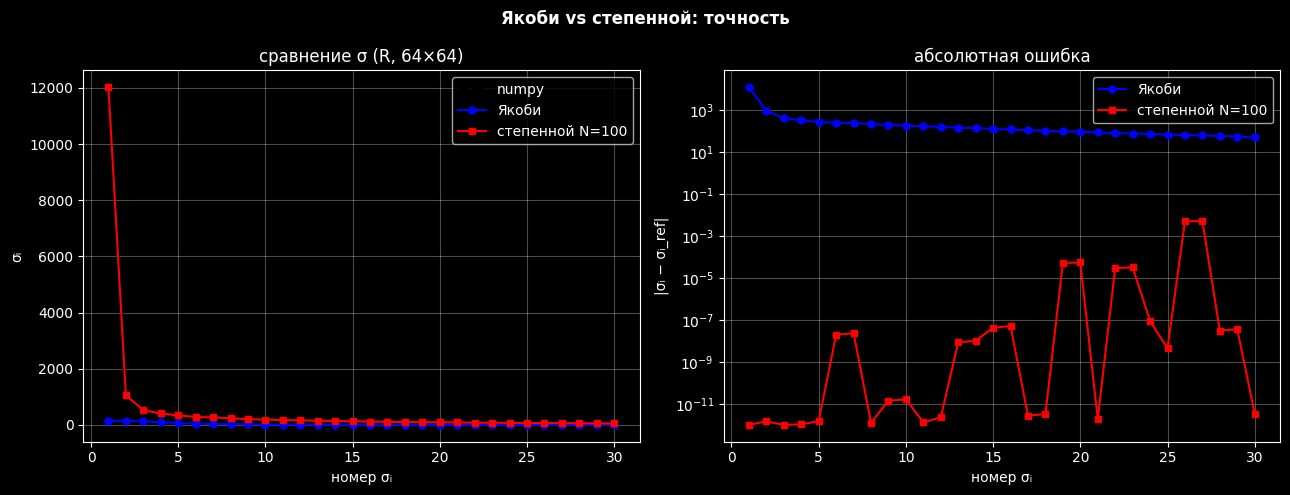


метод                  время, с     операций   макс. ошибка

Якоби                    0.1756   15,202,560   11882.938538
степенной N=100          0.0130   27,004,928       0.005126

Примечание: сравнение на уменьшенной матрице 64×64.
Якоби на полной 640×640 потребовал бы в 1000x больше операций.


In [25]:
k_show = 30
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(range(1, k_show+1), S_ref_sm[:k_show],  'k--', lw=2,   label='numpy')
ax1.plot(range(1, k_show+1), sigma_jac[:k_show],  'b-o', lw=1.5, ms=5, label='Якоби')
ax1.plot(range(1, k_show+1), S_pm_sm[:k_show],    'r-s', lw=1.5, ms=5, label='степенной N=100')
ax1.set_xlabel('номер σᵢ')
ax1.set_ylabel('σᵢ')
ax1.set_title(f'сравнение σ (R, {SZ}×{SZ})')
ax1.legend()
ax1.grid(alpha=0.3)

err_jac = np.abs(sigma_jac[:k_show] - S_ref_sm[:k_show])
err_pm  = np.abs(S_pm_sm[:k_show]   - S_ref_sm[:k_show])
ax2.semilogy(range(1, k_show+1), err_jac + 1e-12, 'b-o', lw=1.5, ms=5, label='Якоби')
ax2.semilogy(range(1, k_show+1), err_pm  + 1e-12, 'r-s', lw=1.5, ms=5, label='степенной N=100')
ax2.set_xlabel('номер σᵢ')
ax2.set_ylabel('|σᵢ − σᵢ_ref|')
ax2.set_title('абсолютная ошибка')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Якоби vs степенной: точность', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n{"метод":<20} {"время, с":>10} {"операций":>12} {"макс. ошибка":>14}')
print()
print(f'{"Якоби":<20} {t_jac:>10.4f} {ops_jac:>12,} {np.max(err_jac):>14.6f}')
print(f'{"степенной N=100":<20} {t_pm:>10.4f} {ops_pm:>12,} {np.max(err_pm):>14.6f}')
print(f'\nПримечание: сравнение на уменьшенной матрице {SZ}×{SZ}.')
print(f'Якоби на полной 640×640 потребовал бы в {(640//SZ)**3:.0f}x больше операций.')

## 7. Творческое задание

### 7.1 Гистограммы распределения пикселей

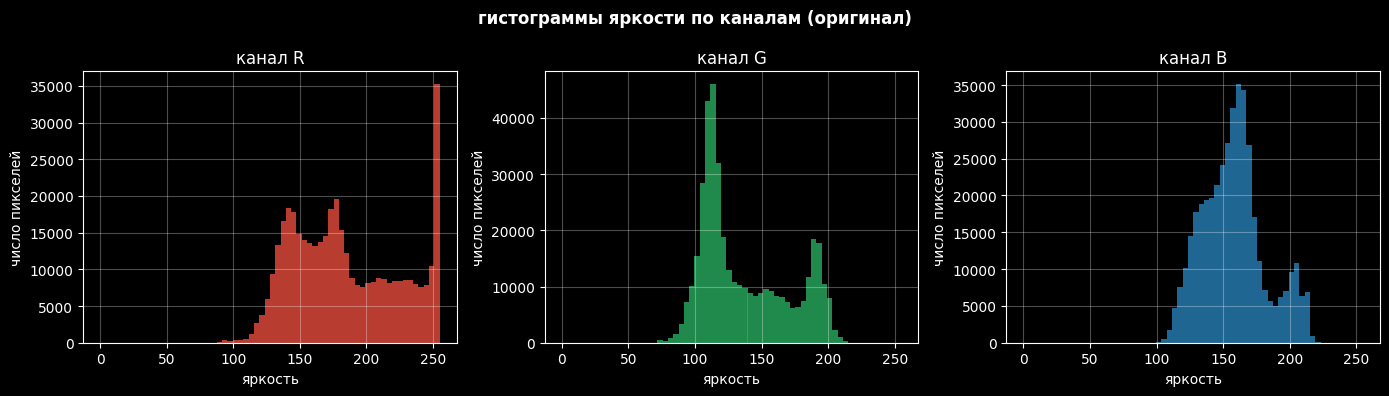

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_ch = {'R': '#e74c3c', 'G': '#27ae60', 'B': '#2980b9'}

for ax, ch_name in zip(axes, ['R', 'G', 'B']):
    counts, bins = np.histogram(channels[ch_name].ravel(), bins=64, range=(0, 255))
    cx = (bins[:-1] + bins[1:]) / 2
    ax.bar(cx, counts, width=4, color=colors_ch[ch_name], alpha=0.8)
    ax.set_title(f'канал {ch_name}')
    ax.set_xlabel('яркость')
    ax.set_ylabel('число пикселей')
    ax.grid(alpha=0.3)

plt.suptitle('гистограммы яркости по каналам (оригинал)', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Как SVD влияет на гистограмму яркости

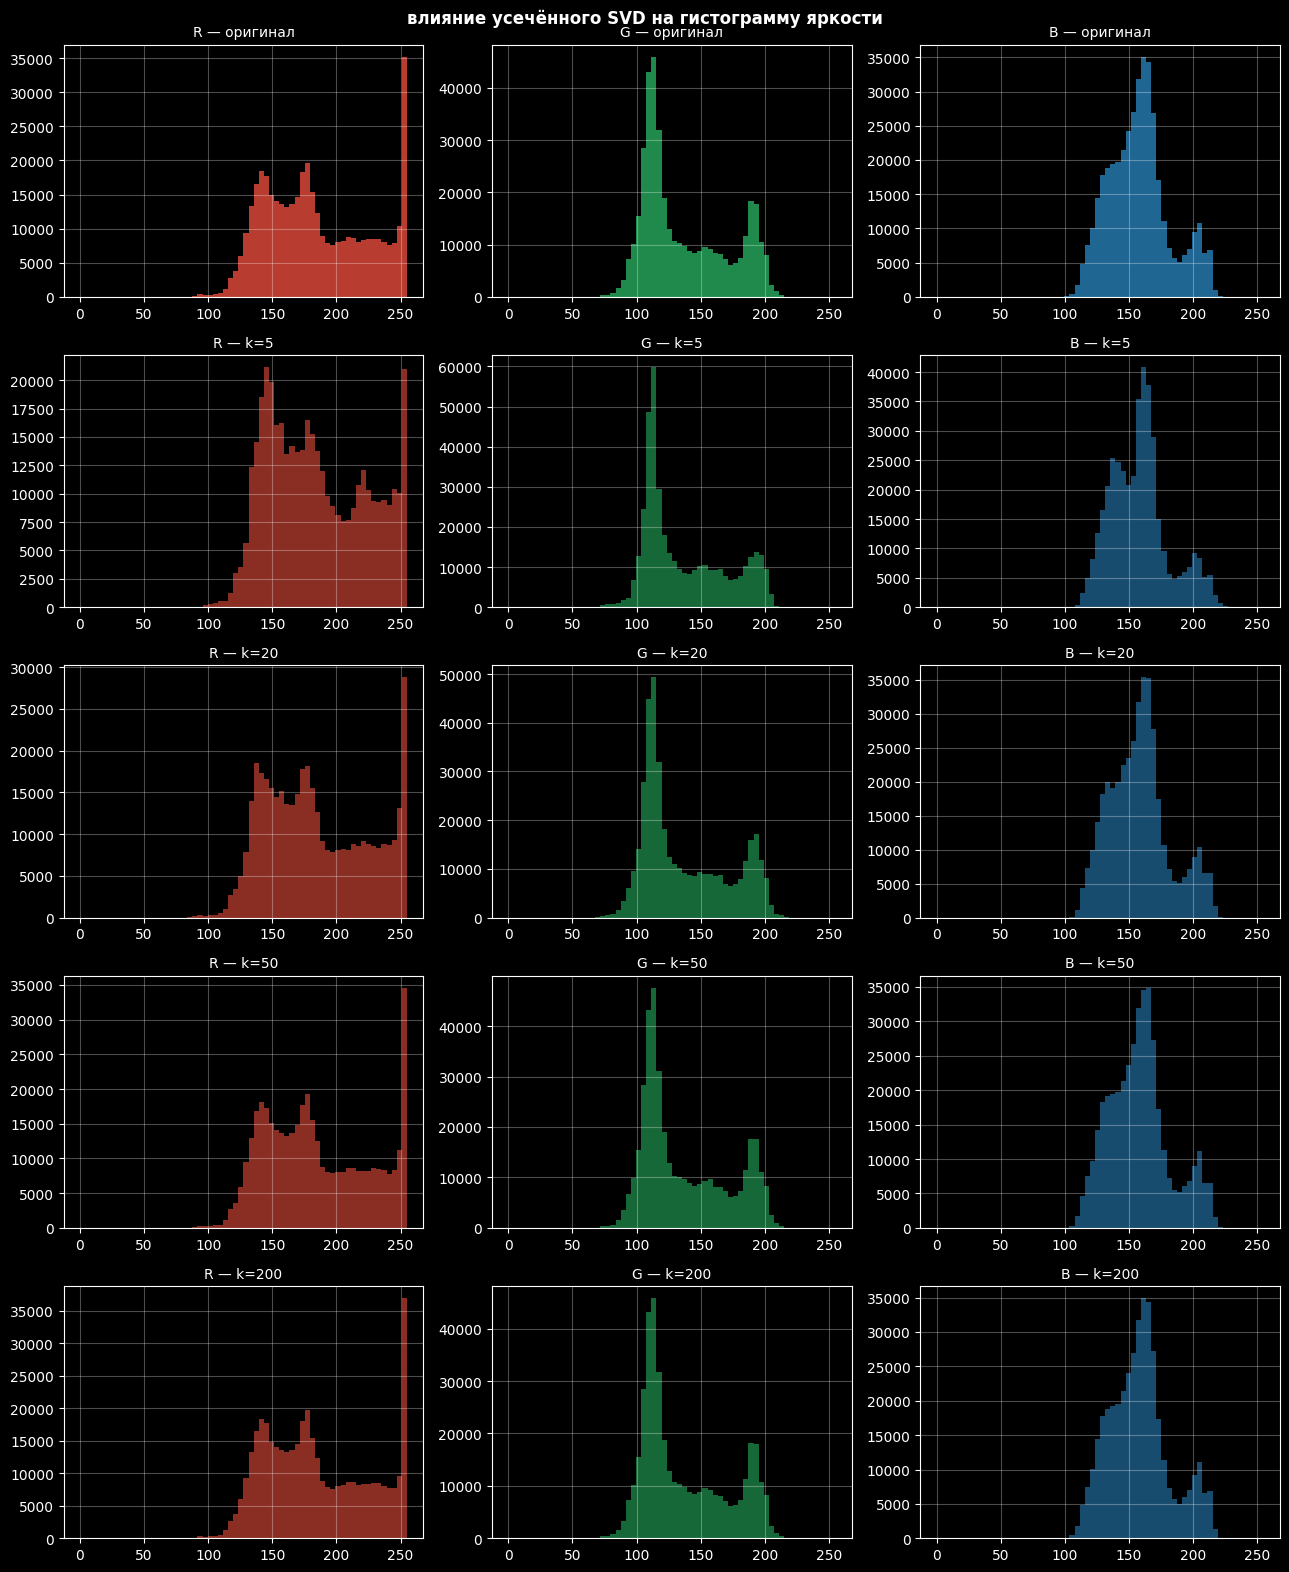

In [20]:
K_hist = [5, 20, 50, 200]
fig, axes = plt.subplots(len(K_hist)+1, 3, figsize=(13, 16))

for col, ch_name in enumerate(['R', 'G', 'B']):
    counts, bins = np.histogram(channels[ch_name].ravel(), bins=64, range=(0,255))
    axes[0, col].bar((bins[:-1]+bins[1:])/2, counts, width=4,
                     color=colors_ch[ch_name], alpha=0.8)
    axes[0, col].set_title(f'{ch_name} — оригинал', fontsize=10)
    axes[0, col].grid(alpha=0.3)

    for row, k in enumerate(K_hist):
        U, S, Vt = ref_svd[ch_name]
        A_k = np.clip(U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :], 0, 255).ravel()
        counts_k, bins_k = np.histogram(A_k, bins=64, range=(0,255))
        axes[row+1, col].bar((bins_k[:-1]+bins_k[1:])/2, counts_k, width=4,
                              color=colors_ch[ch_name], alpha=0.6)
        axes[row+1, col].set_title(f'{ch_name} — k={k}', fontsize=10)
        axes[row+1, col].grid(alpha=0.3)

plt.suptitle('влияние усечённого SVD на гистограмму яркости', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Применение SVD: выделение контуров

Если вычесть из оригинала его низкочастотное SVD-приближение, остаётся высокочастотная часть — то есть края и текстуры. Нашёл идею на основе того что первые k компонент SVD — это что-то вроде "сглаживания", а оставшееся — детали.

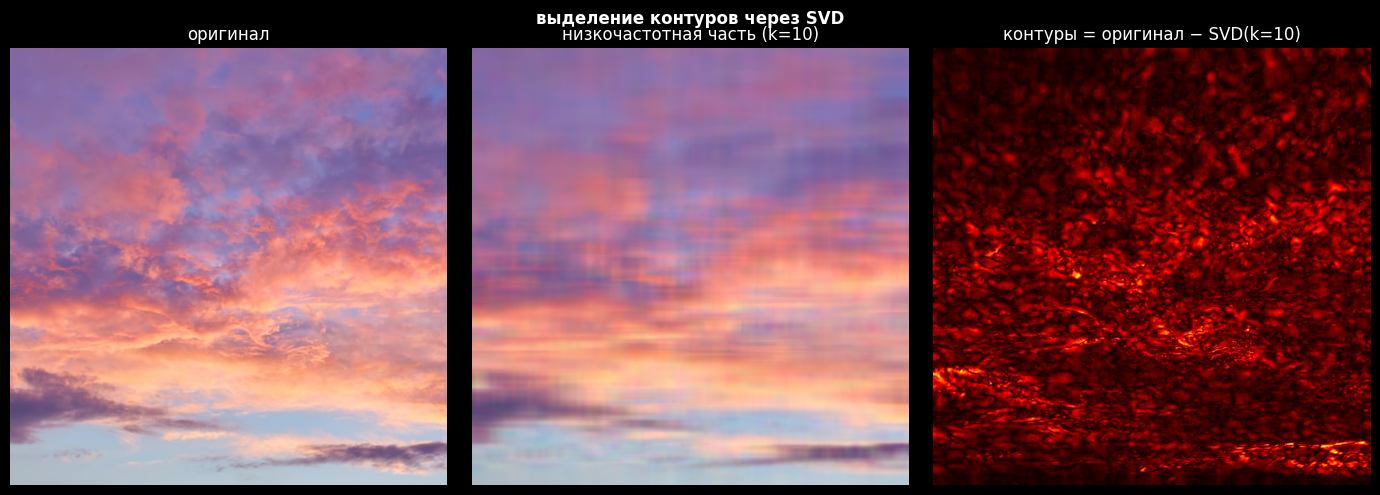

In [21]:
K_low = 10
edge_ch = []
for ch_name in ['R', 'G', 'B']:
    U, S, Vt = ref_svd[ch_name]
    A_low  = U[:, :K_low] @ np.diag(S[:K_low]) @ Vt[:K_low, :]
    edge_ch.append(channels[ch_name] - A_low)

edge_amp = np.mean(np.abs(np.stack(edge_ch, axis=2)), axis=2)
edge_norm = (edge_amp - edge_amp.min()) / (edge_amp.max() - edge_amp.min() + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img.astype(np.uint8))
axes[0].set_title('оригинал')
axes[0].axis('off')

axes[1].imshow(reconstruct_image(ref_svd, K_low))
axes[1].set_title(f'низкочастотная часть (k={K_low})')
axes[1].axis('off')

axes[2].imshow(edge_norm, cmap='hot')
axes[2].set_title(f'контуры = оригинал − SVD(k={K_low})')
axes[2].axis('off')

plt.suptitle('выделение контуров через SVD', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Анализ результатов

**Как число итераций влияет на точность?**  
При N=10 результат заметно хуже — особенно для старших сингулярных чисел где разрыв между соседними значениями мал. При N=50–100 точность уже близка к эталону. Увеличение N дальше 100 практически не меняет результат — метод уже сошёлся.

**Минимальное k для приемлемого качества?**  
По таблице PSNR и визуально: начиная с k≈30–50 изображение практически неотличимо от оригинала. При этом сжатие всё ещё в 6–10 раз. При k=10 картинка размытая, но узнаваемая.

**Какой метод эффективнее по числу операций?**  
Степенной метод при k≪n выигрывает — нужно $O(k \cdot N \cdot n^2)$ операций. Якоби работает со всей матрицей за $O(n^3)$ развёрток и оправдан только когда нужны все собственные значения или матрица маленькая.

**Различия по каналам?**  
Распределение сингулярных чисел по каналам R, G, B похожее. Небольшие отличия в абсолютных значениях $\sigma_1$ объясняются разной интенсивностью каналов на конкретном изображении. Форма спектра у всех каналов одинакова — быстрое убывание.

**Степень сжатия?**  
При хранении усечённого SVD ранга k нужно $k(H+W+1)$ чисел на канал вместо $H \cdot W$. Для k=50 при размере 640×640:
$$\text{сжатие} = \frac{640 \times 640}{50 \times (640+640+1)} \approx 6.4\times$$

In [26]:
# итоговая таблица
print('итог: PSNR и сжатие при разных k')
print(f'{"k":>6} {"PSNR, дБ":>12} {"сжатие":>10}')
print()
for k in [10, 20, 50, 100, 200]:
    img_rec = reconstruct_image(ref_svd, k)
    mse = np.mean((img.astype(float) - img_rec.astype(float))**2)
    psnr = 10 * np.log10(255**2 / mse) if mse > 0 else 999.0
    comp = (H * W * 3) / (k * (H + W + 1) * 3)
    print(f'{k:>6} {psnr:>12.2f} {comp:>9.2f}x')

итог: PSNR и сжатие при разных k
     k     PSNR, дБ     сжатие

    10        31.41     31.98x
    20        35.11     15.99x
    50        41.59      6.40x
   100        47.24      3.20x
   200        51.06      1.60x


## 9. Выводы

1. **Степенной метод** нормально справляется с нахождением первых k сингулярных чисел. При N≥50 точность хорошая. При N=10 возможны проблемы с точностью у старших компонент — из-за накопленных ошибок дефляции оценки λ могут уйти в минус.

2. **Усечённое SVD** хорошо работает для сжатия изображений. Уже при k=50 из 640 PSNR>35дБ и сжатие ~6×. Это подтверждает что большинство информации в изображении сосредоточено в нескольких первых сингулярных компонентах.

3. **Метод Якоби** точнее и находит сразу все собственные значения, но слишком медленный для больших матриц. Для сжатия изображений лучше подходит степенной метод.

4. SVD можно использовать не только для сжатия, но и для выделения контуров — разность оригинала и низкоранговой аппроксимации даёт высокочастотные детали изображения.